### KERAS CLASSIFIER MODELING

Models are built using Keras Classifier.

**Import libraries**

In [ ]:
!pip install scikit-learn==1.3.2
!pip install scikeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


**Load cleaned dataset**

In [ ]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data_ccf.csv')

In [ ]:
# Define X and y then split into train and test sets
X = df.drop(columns="is_fraud")
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Verify number of features

print(f'There are {len(X_train.columns)} features.')

There are 19 features.


In [ ]:
# Set seed
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Identify columns for preprocessing
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [ ]:
# Define the preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols)
])

In [ ]:
# Define the callback for early stop (prevents overfitting and reduces training time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# Fit and transform data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
# Define create model function
tf.random.set_seed(42)
def create_model(optimizer='adam', neurons=50, activation='relu', dropout_rate=0.2, input_shape=None):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(neurons,
                                    activation=activation,
                                    input_shape=(X_train_transformed.shape[1:])))
    model.add(Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Define the parameter grid
param_grid = {
    'model__neurons': [25, 50, 100],
    'model__activation': ['relu', 'tanh'],
    'model__optimizer': ['adam', 'sgd'],
    'model__dropout_rate': [0.2, 0.3],
    'batch_size': [16, 32],
    'epochs': [100]
}

In [ ]:
# Address class imbalance with class_weight
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{0: 0.5043288223921997, 1: 58.25242718446602}


In [ ]:
# Set seed to control randomness in neural networks
tf.random.set_seed(42)

# Build the model, grid search and fit including class_weight and callbacks
model = KerasClassifier(model=create_model, input_shape=X_train_transformed.shape[1:], verbose=0)

grid = HalvingRandomSearchCV(model, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid_result = grid.fit(X_train_transformed, y_train, class_weight=class_weights, callbacks=[early_stop])

print(grid_result.best_params_, '\n')
print(grid_result.best_score_)

{'model__optimizer': 'adam', 'model__neurons': 100, 'model__dropout_rate': 0.3, 'model__activation': 'tanh', 'epochs': 100, 'batch_size': 32} 

0.0


In [ ]:
# Obtain best parameters and score

print(f'Best parameters: {grid_result.best_params_}')
print(f'Best score: {grid_result.best_score_:.4f}')

Best parameters: {'model__optimizer': 'adam', 'model__neurons': 100, 'model__dropout_rate': 0.3, 'model__activation': 'tanh', 'epochs': 100, 'batch_size': 32}
Best score: 0.0000


In [ ]:
# Accuracy of model on train and test data
best_model = grid_result.best_estimator_

best_model_acc_train = best_model.score(X_train_transformed, y_train)
best_model_acc_test = best_model.score(X_test_transformed, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 98.05%
The test accuracy of the model is 98.12%


In [ ]:
# Evaluate the best model
y_pred = best_model.predict(X_test_transformed)
y_proba = best_model.predict_proba(X_test_transformed)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5948
           1       0.27      0.69      0.39        52

    accuracy                           0.98      6000
   macro avg       0.63      0.84      0.69      6000
weighted avg       0.99      0.98      0.99      6000

ROC AUC: 0.9600738451192385
PR AUC: 0.5117233024114929


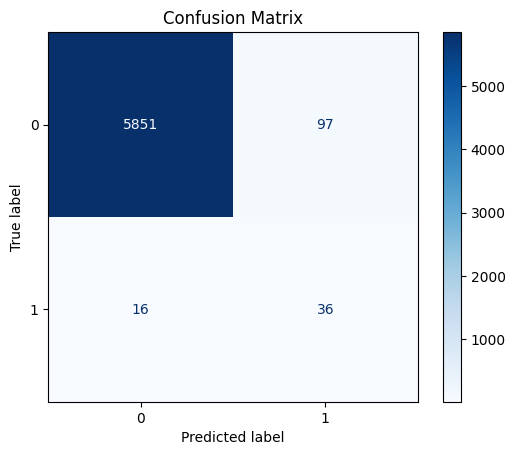

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 97 
 fn: 16 
 tp: 36 
 tn: 5851


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.98
Precision: 0.27
Recall: 0.69


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.5279


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of fraud is \$800      
**C** = cost of preventive action is \$40     
True positives (**TP**) are correctly identified frauds (preventive action is spent but the value is saved).   
False positives (**FP**) are not fraudulent but predicted to be fraudulent (preventive action is spent but no value is saved).    
False negatives (**FN)** are predicted not to be fraudulent but actually fraudulent (no prevention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to be fraudulent (no prevention action spent and no value is lost).

In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $10680


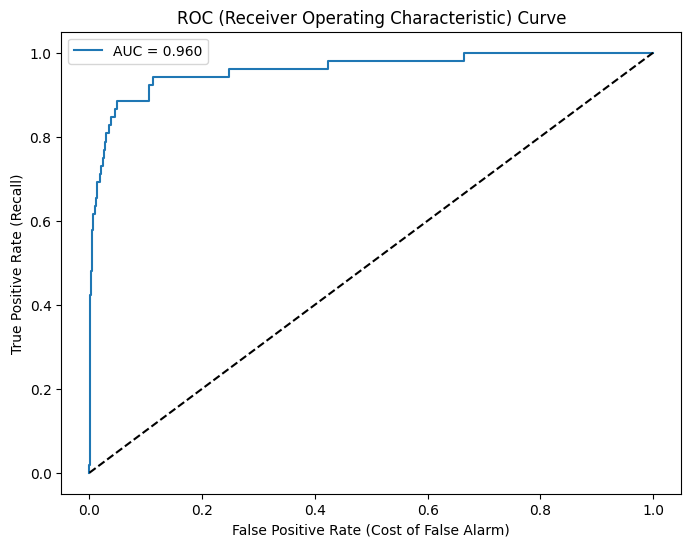

In [ ]:
# Plot the ROC Curve
y_proba = best_model.predict_proba(X_test_transformed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = round(roc_auc_score(y_test, y_proba), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold:.2f}')

The optimal threshold is 0.08


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

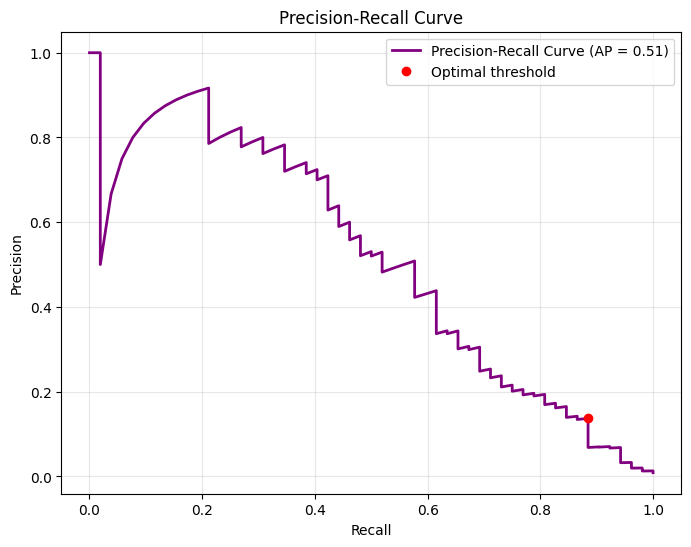

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.20, 0.01)
for threshold in thresholds:
    preds = (y_proba >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.01 | Recall=1.00
Threshold=0.01 | Precision=0.07 | Recall=0.92
Threshold=0.02 | Precision=0.09 | Recall=0.88
Threshold=0.03 | Precision=0.10 | Recall=0.88
Threshold=0.04 | Precision=0.11 | Recall=0.88
Threshold=0.05 | Precision=0.12 | Recall=0.88
Threshold=0.06 | Precision=0.13 | Recall=0.88
Threshold=0.07 | Precision=0.13 | Recall=0.88
Threshold=0.08 | Precision=0.14 | Recall=0.87
Threshold=0.09 | Precision=0.14 | Recall=0.85
Threshold=0.10 | Precision=0.15 | Recall=0.85
Threshold=0.11 | Precision=0.15 | Recall=0.85
Threshold=0.12 | Precision=0.16 | Recall=0.85
Threshold=0.13 | Precision=0.16 | Recall=0.85
Threshold=0.14 | Precision=0.17 | Recall=0.83
Threshold=0.15 | Precision=0.17 | Recall=0.83
Threshold=0.16 | Precision=0.17 | Recall=0.83
Threshold=0.17 | Precision=0.17 | Recall=0.81
Threshold=0.18 | Precision=0.18 | Recall=0.81
Threshold=0.19 | Precision=0.18 | Recall=0.81


In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.07


In [ ]:
# Use the threshold that maximizes profit
y_pred = (y_proba >= best_threshold).astype(int)

In [ ]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      5948
           1       0.13      0.88      0.23        52

    accuracy                           0.95      6000
   macro avg       0.57      0.92      0.60      6000
weighted avg       0.99      0.95      0.97      6000



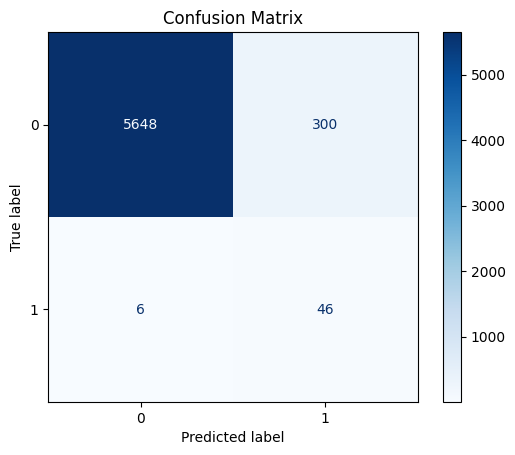

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 300 
 fn: 6 
 tp: 46 
 tn: 5648


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.95
Precision: 0.13
Recall: 0.88


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.4152


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $18160


**Feature Selection**    
SelectKBest tries to select the top features.


In [ ]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[1] for name in feature_names]   # Clean the feature names

print(feature_names, '\n')
print(f'There are {len(feature_names)} feature names.')

['city_pop', 'zip_region', 'time_delta', 'amt_vs_avg', 'dist_to_merch', 'travel_speed', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_night', 'is_weekend', 'age', 'amt_log', 'high_amt', 'merchant_freq', 'missing_merch_zip', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_M'] 

There are 32 feature names.


In [ ]:
# Define neural network
def build_model(meta, learning_rate=0.001):

    input_dim = meta["n_features_in_"]   # input dimension automatically detected

    model = Sequential()

    model.add(Dense(64, activation="relu", input_dim=input_dim))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(28, 34, 2)
for i in features:
  tf.random.set_seed(42)
  # Wrap keras model
  model = KerasClassifier(
      model=build_model,
      learning_rate=0.001,
      epochs=50,
      batch_size=32,
      verbose=0
  )
  # Feature selection
  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build pipeline
  pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('selection', selector),
      ('keras', model)
  ])
  # Train the model
  pipe.fit(X_train, y_train, keras__class_weight=class_weights, keras__callbacks=[early_stop])
  # Set up parameter grid
  param_grid = {
      "keras__epochs": [20, 30],
      "keras__batch_size": [32, 64],
      "keras__learning_rate": [0.0005, 0.001, 0.005]
  }
  # Run HalvingRandomSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid = HalvingRandomSearchCV(
      pipe,
      param_grid,
      scoring="f1",
      cv=cv,
      n_jobs=-1
  )
  grid.fit(X_train, y_train, keras__class_weight=class_weights, keras__callbacks=[early_stop])
  # Access the optimized pipeline model
  best_model = grid.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 28 | AUC = 0.9613
Number of Features = 30 | AUC = 0.9612
Number of Features = 32 | AUC = 0.9547


In [ ]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 28.


In [ ]:
# Wrap keras model
tf.random.set_seed(42)

model = KerasClassifier(
    model=build_model,
    learning_rate=0.001,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [ ]:
# Feature selection
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [ ]:
# Build pipeline
tf.random.set_seed(42)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selection', selector),
    ('keras', model)
])
pipe.fit(X_train, y_train, keras__class_weight=class_weights, keras__callbacks=[early_stop])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [ ]:
# Set up parameter grid
param_grid = {
    "keras__epochs": [20, 30],
    "keras__batch_size": [32, 64],
    "keras__learning_rate": [0.0005, 0.001, 0.005]
}

In [ ]:
# Run HalvingRandomSearchCV
tf.random.set_seed(42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train, y_train, keras__class_weight=class_weights, keras__callbacks=[early_stop])

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'keras__learning_rate': 0.001, 'keras__epochs': 30, 'keras__batch_size': 64}
Best score: 0.0000


In [ ]:
# Access the optimized pipeline model
best_model = grid.best_estimator_

In [ ]:
# Accuracy on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 99.20%
The test accuracy of the model is 98.82%


In [ ]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5948
           1       0.39      0.62      0.47        52

    accuracy                           0.99      6000
   macro avg       0.69      0.80      0.73      6000
weighted avg       0.99      0.99      0.99      6000



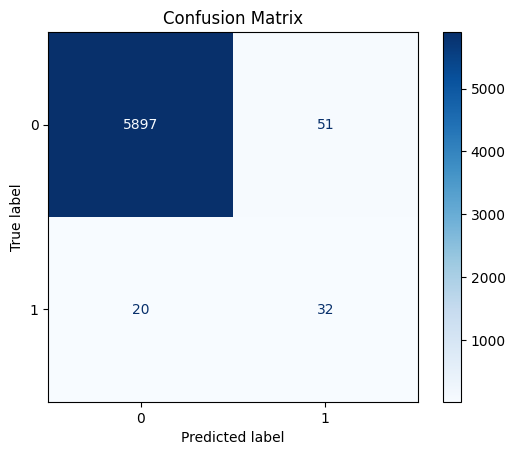

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 51 
 fn: 20 
 tp: 32 
 tn: 5897


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.99
Precision: 0.39
Recall: 0.62


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.5498


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $6280


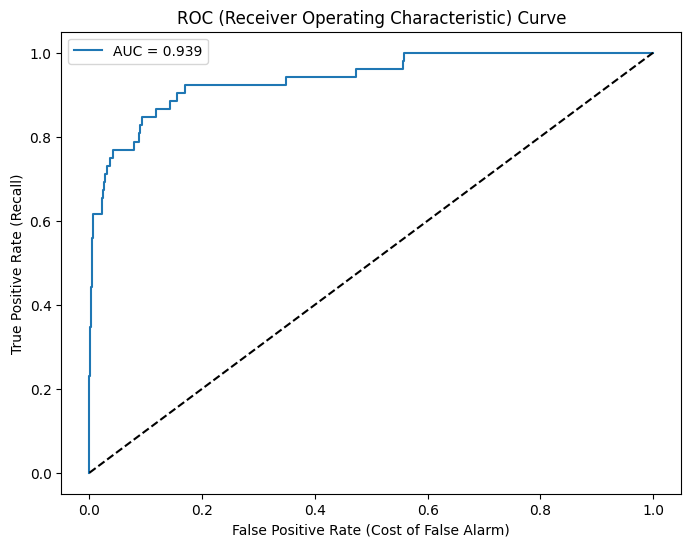

In [ ]:
# Plot the ROC Curve
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = round(roc_auc_score(y_test, y_proba), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold:.2f}')

The optimal threshold is 0.00


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

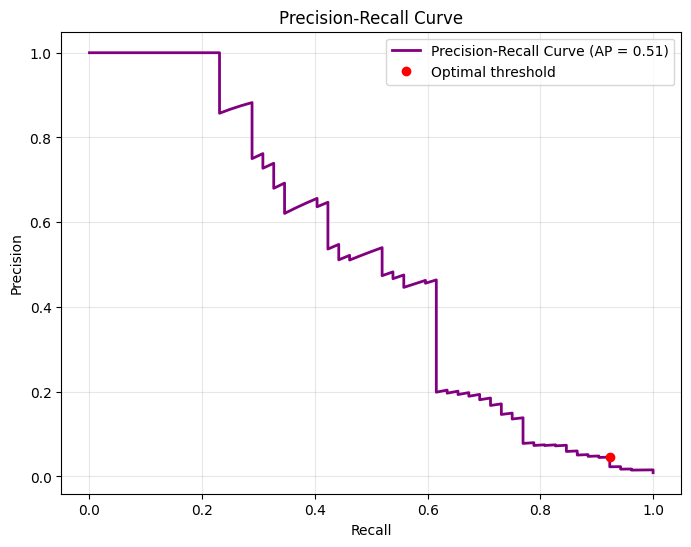

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.30, 0.01)
for threshold in thresholds:
    preds = (y_proba >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.01 | Recall=1.00
Threshold=0.01 | Precision=0.14 | Recall=0.75
Threshold=0.02 | Precision=0.17 | Recall=0.73
Threshold=0.03 | Precision=0.18 | Recall=0.71
Threshold=0.04 | Precision=0.18 | Recall=0.69
Threshold=0.05 | Precision=0.19 | Recall=0.69
Threshold=0.06 | Precision=0.19 | Recall=0.67
Threshold=0.07 | Precision=0.20 | Recall=0.65
Threshold=0.08 | Precision=0.20 | Recall=0.63
Threshold=0.09 | Precision=0.20 | Recall=0.62
Threshold=0.10 | Precision=0.21 | Recall=0.62
Threshold=0.11 | Precision=0.21 | Recall=0.62
Threshold=0.12 | Precision=0.22 | Recall=0.62
Threshold=0.13 | Precision=0.22 | Recall=0.62
Threshold=0.14 | Precision=0.23 | Recall=0.62
Threshold=0.15 | Precision=0.23 | Recall=0.62
Threshold=0.16 | Precision=0.24 | Recall=0.62
Threshold=0.17 | Precision=0.25 | Recall=0.62
Threshold=0.18 | Precision=0.25 | Recall=0.62
Threshold=0.19 | Precision=0.26 | Recall=0.62
Threshold=0.20 | Precision=0.27 | Recall=0.62
Threshold=0.21 | Precision=0.28 | 

In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.02


In [ ]:
# Use the threshold that maximizes profit
y_pred = (y_proba >= best_threshold).astype(int)

In [ ]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      5948
           1       0.17      0.73      0.27        52

    accuracy                           0.97      6000
   macro avg       0.58      0.85      0.63      6000
weighted avg       0.99      0.97      0.98      6000



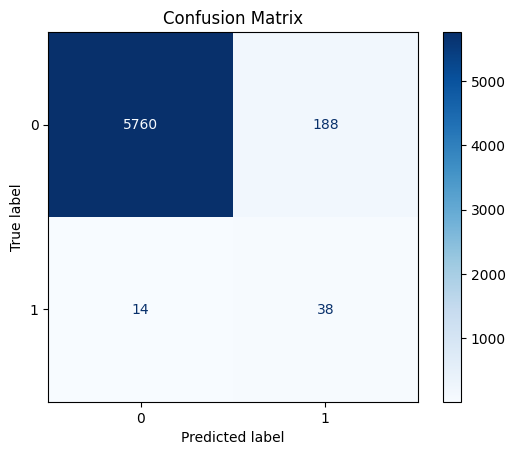

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 188 
 fn: 14 
 tp: 38 
 tn: 5760


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.97
Precision: 0.17
Recall: 0.73


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.4378


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $10160


**Feature Importance**


In [ ]:
# Access the selector
selector = best_model.named_steps["selection"]

In [ ]:
# Get scores and selected features
scores = selector.scores_
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names
selected_scores = scores[mask]

print(selected_features, '\n')
print(f'There are {len(selected_features)} selected features and {len(selected_scores)} selected scores.')

['city_pop', 'zip_region', 'time_delta', 'amt_vs_avg', 'dist_to_merch', 'travel_speed', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_night', 'is_weekend', 'age', 'amt_log', 'high_amt', 'merchant_freq', 'missing_merch_zip', 'category_gas_transport', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_M'] 

There are 28 selected features and 28 selected scores.


In [ ]:
# Match features to scores
feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': selected_scores
}).sort_values(by='importance', ascending=False)

In [ ]:
# Reset index
feature_importance_df = feature_importance_df.reset_index(drop=True)
feature_importance_df.index = feature_importance_df.index + 1
feature_importance_df.index.name = "Rank"

feature_importance_df.head(10)

,feature,importance
Rank,,
1,amt_log,0.023660
2,high_amt,0.015975
3,amt_vs_avg,0.011885
4,hour_cos,0.005707
5,age,0.003849
6,city_pop,0.003783
7,hour_sin,0.003543
8,is_night,0.002955
9,dow_cos,0.002638


In [ ]:
# Select the first twenty features
feature_importance_df = feature_importance_df.iloc[:20]

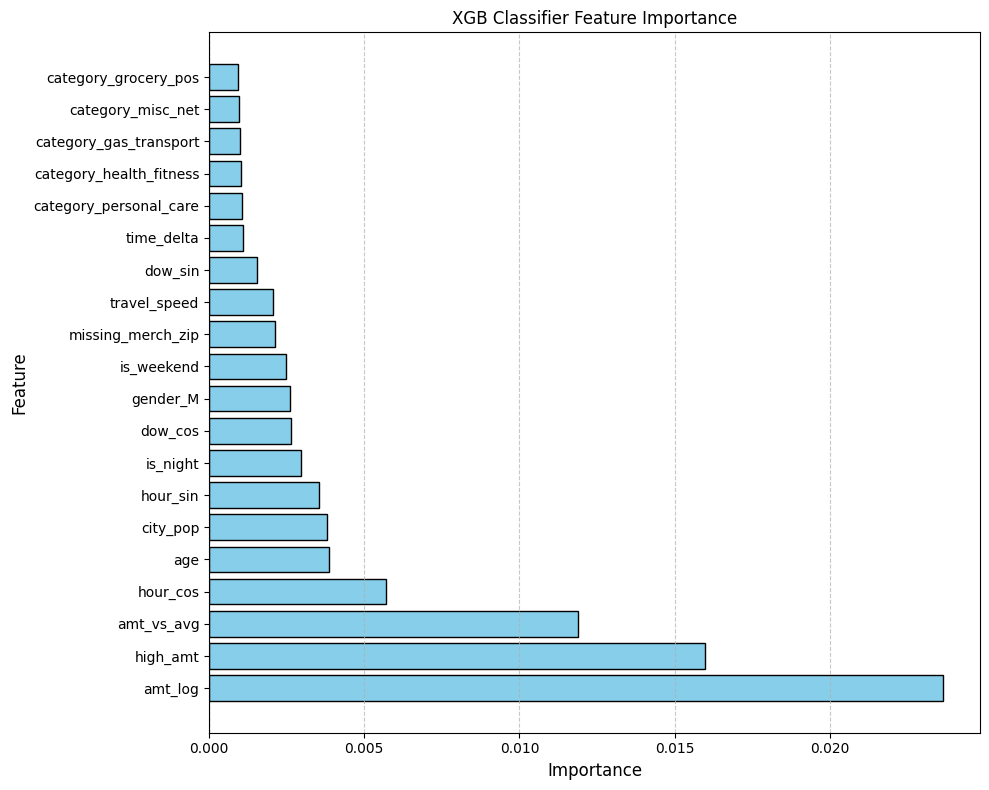

In [ ]:
# Plot the features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_importance_df['importance']]
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('XGB Classifier Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     

A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The final predictive model would need to consider the actual relative cost of missing a fraudulent transaction (false negatives - predicted not fraudulent but fraudulent) and false alarms (false positives - predicted fraudulent but actually not fraudulent) in order to determine the optimum mix of precision and recall.  

In [ ]:
# Build a dataframe
keras_model_df = pd.DataFrame({
    'Classifier': ['Keras'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2 Score': [F2_score],
    'Profit/Loss': [Profit_Loss],
})
keras_model_df

,Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Keras,0.939,0.966333,0.168142,0.730769,0.437788,10160


In [ ]:
# Output the XGBoost model performance metrics
keras_model_df.to_csv("keras_model.csv", index=False)

In [ ]:
# Output the XGBoost) features importance
feature_importance_df.to_csv("keras_features.csv", index=False)

**Sample Predictions**

In [ ]:
# List indices of fraudulent transactions
fraud_idx = y_test[y_test == 1].index

print(fraud_idx)

Index([26553,  5765,  6255,  4010,  3435,  7576, 29804, 18741,  2644,    81,
       12242, 18998, 27870, 13027, 24183, 25204,  7258, 17990,  9465, 13028,
         200, 16553, 24184, 23247, 22416, 10690, 12244,  2641,  9925,  7730,
       16352,   925, 22230,  2847,  1330, 24779, 10926, 16215,  8460, 28115,
       13059, 27688, 14839, 27600, 22415, 28114, 13324,  8461, 22229, 24480,
       15680, 20559],
      dtype='int64')


**Sample 1**

In [ ]:
# Obtain a sample from the test data
df_test1 = X_test.loc[26553]

print(df_test1, '\n')
print(f'Actual fraud status is {y_test.loc[26553]}')

category             shopping_pos
gender                          F
city_pop                   276002
zip_region                      3
time_delta              67.683333
amt_vs_avg               3.770236
dist_to_merch           16.125745
travel_speed            14.295169
hour_sin                -0.258819
hour_cos                 0.965926
dow_sin                  0.974928
dow_cos                 -0.222521
is_night                        0
is_weekend                      0
age                            69
amt_log                  6.852834
high_amt                        1
merchant_freq                  48
missing_merch_zip               0
Name: 26553, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample1 = {
    "category": "shopping_pos",
    "gender": "F",
    "city_pop": 276002,
    "zip_region": 3,
    "time_delta": 67.683333,
    "amt_vs_avg": 3.770236,
    "dist_to_merch": 16.125745,
    "travel_speed": 14.295169,
    "hour_sin": -0.258819,
    "hour_cos": 0.965926,
    "dow_sin": 0.974928,
    "dow_cos": -0.222521,
    "is_night": 0,
    "is_weekend": 0,
    "age": 69,
    "amt_log": 6.852834,
    "high_amt": 1,
    "merchant_freq": 48,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability1 = best_model.predict_proba(pd.DataFrame([sample1]))[1]

if probability1 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability1:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 1.00


**Sample 2**

In [ ]:
# Obtain a sample from the test data
df_test2 = X_test.loc[5765]

print(df_test2, '\n')
print(f'Actual fraud status is {y_test.loc[5765]}')

category             grocery_pos
gender                         F
city_pop                     602
zip_region                     6
time_delta               3169.25
amt_vs_avg              3.997849
dist_to_merch          66.154038
travel_speed            1.252423
hour_sin                0.258819
hour_cos               -0.965926
dow_sin                -0.974928
dow_cos                -0.222521
is_night                       0
is_weekend                     1
age                           65
amt_log                 5.908871
high_amt                       1
merchant_freq                 58
missing_merch_zip              0
Name: 5765, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample2 = {
    "category": "grocery_pos",
    "gender": "F",
    "city_pop": 602,
    "zip_region": 6,
    "time_delta": 3169.25,
    "amt_vs_avg": 3.997849,
    "dist_to_merch": 66.154038,
    "travel_speed": 1.252423,
    "hour_sin": 0.258819,
    "hour_cos": -0.965926,
    "dow_sin": -0.974928,
    "dow_cos": -0.222521,
    "is_night": 0,
    "is_weekend": 1,
    "age": 65,
    "amt_log": 5.908871,
    "high_amt": 1,
    "merchant_freq": 58,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability2 = best_model.predict_proba(pd.DataFrame([sample2]))[1]

if probability2 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability2:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.96


**Sample 3**

In [ ]:
# Obtain a sample from the test data
df_test3 = X_test.loc[200]

print(df_test3, '\n')
print(f'Actual fraud status is {y_test.loc[200]}')

category             grocery_pos
gender                         F
city_pop                    1439
zip_region                     9
time_delta                  -1.0
amt_vs_avg              0.947413
dist_to_merch          59.157745
travel_speed        -3549.464675
hour_sin                     0.5
hour_cos                0.866025
dow_sin                -0.781831
dow_cos                  0.62349
is_night                       1
is_weekend                     1
age                           20
amt_log                 5.601233
high_amt                       1
merchant_freq                 66
missing_merch_zip              0
Name: 200, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample3 = {
    "category": "grocery_pos",
    "gender": "F",
    "city_pop": 1439,
    "zip_region": 9,
    "time_delta": -1.0,
    "amt_vs_avg": 0.947413,
    "dist_to_merch": 59.157745,
    "travel_speed": -3549.464675,
    "hour_sin": 0.5,
    "hour_cos": 0.866025,
    "dow_sin": -0.781831,
    "dow_cos": 0.62349,
    "is_night": 1,
    "is_weekend": 1,
    "age": 20,
    "amt_log": 5.601233,
    "high_amt": 1,
    "merchant_freq": 66,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability3 = best_model.predict_proba(pd.DataFrame([sample3]))[1]

if probability3 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability3:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.92


**Sample 4**

In [ ]:
# Obtain a sample from the test data
df_test4 = X_test.loc[10926]

print(df_test4, '\n')
print(f'Actual fraud status is {y_test.loc[10926]}')

category              grocery_pos
gender                          M
city_pop                  1241364
zip_region                      9
time_delta           10367.466667
amt_vs_avg               2.772653
dist_to_merch           39.560374
travel_speed             0.228949
hour_sin                 0.707107
hour_cos                 0.707107
dow_sin                       0.0
dow_cos                       1.0
is_night                        1
is_weekend                      0
age                            32
amt_log                  5.627585
high_amt                        1
merchant_freq                  63
missing_merch_zip               1
Name: 10926, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample4 = {
    "category": "grocery_pos",
    "gender": "M",
    "city_pop": 1241364,
    "zip_region": 9,
    "time_delta": 10367.466667,
    "amt_vs_avg": 2.772653,
    "dist_to_merch": 39.560374,
    "travel_speed": 0.228949,
    "hour_sin": 0.707107,
    "hour_cos": 0.707107,
    "dow_sin": 0.0,
    "dow_cos": 1.0,
    "is_night": 1,
    "is_weekend": 0,
    "age": 32,
    "amt_log": 5.627585,
    "high_amt": 1,
    "merchant_freq": 63,
    "missing_merch_zip": 1
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability4 = best_model.predict_proba(pd.DataFrame([sample4]))[1]

if probability4 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability4:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 1.00


**Sample 5**

In [ ]:
# Obtain a sample from the test data
df_test5 = X_test.loc[14839]

print(df_test5, '\n')
print(f'Actual fraud status is {y_test.loc[14839]}')

category             shopping_pos
gender                          F
city_pop                    31394
zip_region                      4
time_delta                 1146.7
amt_vs_avg              11.244951
dist_to_merch           46.099177
travel_speed             2.412096
hour_sin                -0.258819
hour_cos                 0.965926
dow_sin                       0.0
dow_cos                       1.0
is_night                        0
is_weekend                      0
age                            23
amt_log                  6.559049
high_amt                        1
merchant_freq                  58
missing_merch_zip               0
Name: 14839, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample5 = {
    "category": "shopping_pos",
    "gender": "F",
    "city_pop": 31394,
    "zip_region": 4,
    "time_delta": 1146.7,
    "amt_vs_avg": 11.244951,
    "dist_to_merch": 46.099177,
    "travel_speed": 2.412096,
    "hour_sin": -0.258819,
    "hour_cos": 0.965926,
    "dow_sin": 0.0,
    "dow_cos": 1.0,
    "is_night": 0,
    "is_weekend": 0,
    "age": 23,
    "amt_log": 6.559049,
    "high_amt": 1,
    "merchant_freq": 58,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability5 = best_model.predict_proba(pd.DataFrame([sample5]))[1]

if probability5 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability5:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.68
